# 지하철 승하차 혼잡도 분석 보고서

## 1장. 분석 기획

> **핵심 질문:** 서울 지하철 혼잡 완화를 위해 운영 자원을 어디에, 언제, 어떤 방식으로 우선 배치해야 하는가?

> **Top Message:** 본 분석의 목적은 단순히 사람이 많은 역을 나열하는 것이 아니라, 혼잡 완화를 위해 **피크 시간대, 고혼잡 역, 승하차 방향성**을 기준으로 운영 자원의 우선 배치 기준을 도출하는 것이다.


### 1-1. 문제 정의와 의사결정 질문

| 구분 | 내용 |
|---|---|
| Situation | 서울 지하철 수요는 시간대와 역에 따라 다르다. |
| Complication | 모든 역에 같은 방식으로 자원을 배치하면 실제 혼잡 지점 대응이 어렵다. |
| Question | 운영 자원을 어디에, 언제, 어떤 방식으로 우선 배치해야 하는가? |
| Answer | 피크 시간대와 고혼잡 역 중심의 선별적 혼잡 완화 전략이 필요하다. |


### 1-2. 분석 기준

본 분석은 서울 지하철 시간대별 승하차 데이터로 `시간`, `공간`, `승하차 흐름`을 비교한다. 데이터의 정확한 기간과 단위는 2장에서 검증한다.

| 기준 | 정의 |
|---|---|
| 유동량 | 승차인원 + 하차인원 |
| 피크 유동량 | 출근·퇴근 피크 시간대 유동량 |
| 상대 혼잡도 | 비교 집단 내 최대 유동량 대비 비율 |
| 의사결정 단위 | 역, 노선, 시간대, 월 |

실제 열차 내부 혼잡률은 추가 데이터가 필요하므로 `확인 필요`로 둔다.


### 1-3. 최종 제안 방향

| 제안 | 검증 질문 |
|---|---|
| 피크 시간대 집중 관리 | 출근·퇴근 피크에 유동량이 집중되는가? |
| 고혼잡 역 우선순위 지정 | 특정 노선·역에 유동량이 집중되는가? |
| 승차형·하차형 맞춤 대응 | 승차형·하차형·혼합형 역을 구분할 수 있는가? |
| 월별 혼잡도 모니터링 | 월별 혼잡 패턴이 반복 또는 변화하는가? |


### 1-4. 결론 근거화 구조

본 보고서는 피라미드 구조와 MECE 관점으로 결론을 정리한다.

```text
                         [핵심 주장]
        서울 지하철 혼잡 관리는 전체 평균이 아니라
   피크 시간대, 고혼잡 역, 승하차 방향성을 기준으로
             선별적으로 설계해야 한다
                              │
        ┌────────────────────────┼────────────────────────┐
        │                        │                        │
   [근거 1]                 [근거 2]                 [근거 3]
  시간대별 집중             공간별 집중              흐름별 유형
        │                        │                        │
   [데이터]                 [데이터]                 [데이터]
  시간대별 유동량           노선·역별 유동량         승차·하차 비중
        │                        │                        │
   [통계분석]               [통계분석]               [통계분석]
  Kruskal-Wallis 검정       Kruskal-Wallis 검정      카이제곱 검정
  효과크기 epsilon²         상위 역 유동량 비중      Cramer's V
```

| 축 | 핵심 질문 | 운영 제안 연결 |
|---|---|---|
| 시간 | 언제 혼잡한가? | 피크 시간대 집중 관리 |
| 공간 | 어디가 혼잡한가? | 고혼잡 역 우선순위 지정 |
| 흐름 | 어떤 방향으로 혼잡한가? | 역 유형별 맞춤 대응 |
| 변화 | 시간이 지나며 어떻게 달라졌는가? | 정기 모니터링 기준 구축 |

피라미드 근거는 다음 통계분석으로 검증한다.

| 피라미드 근거 | 통계분석 | 확인 지표 |
|---|---|---|
| 시간대별 집중 | 시간대별 유동량 차이 검정 | Kruskal-Wallis 검정, 효과크기 |
| 공간별 집중 | 노선별 유동량 차이 및 역별 집중도 | Kruskal-Wallis 검정, 상위 역 유동량 비중 |
| 흐름별 유형 | 피크 시간대와 승하차 유형의 연관성 | 카이제곱 검정, Cramer's V |


## 2장. 데이터 점검 및 분석 준비

2장은 1장의 분석 질문을 실제 데이터로 어디까지 검증 가능한지 확인하는 장이다. 원천 데이터 구조, 분석 가능 지표, 전처리 기준을 고정한다.

> **핵심 판단:** 현재 데이터만으로 실제 열차 내부 혼잡률은 계산할 수 없으므로, 본 보고서는 시간대별 승하차 유동량을 이용한 상대적 혼잡도 분석으로 범위를 제한한다.


### 2-1. 데이터 개요

| 파일 | 역할 | 구조 |
|---|---|---|
| `Seoul_subway_data_20210705.csv` | 월·노선·역·시간대별 승하차 인원 | `45,338행`, `52개 컬럼`, `2015년 1월~2021년 6월` |
| `subway_location_data.csv` | 역별 주소 및 좌표 | `579행`, `4개 컬럼` |

승하차 데이터는 월 단위 집계이며, 시간대별 승차·하차 컬럼이 wide 형태로 구성되어 있다. 분석 단위는 월, 노선, 역, 시간대이다.


### 2-2. 분석 가능 범위

| 구분 | 내용 |
|---|---|
| 가능 | 시간대별 승차·하차 인원, 유동량, 피크 유동량, 상대 혼잡도 지수 |
| 확인 필요 | 실제 열차·승강장 혼잡률, 정책 효과, 원인 분석 |
| 주요 한계 | 월 단위 집계이므로 일별 이벤트나 열차 1편 단위 혼잡은 분석 불가 |
| 위치 분석 주의 | 역명 중복, `역` 접미사, 표기 차이로 매칭률 확인 필요 |

본 보고서는 실제 혼잡률이 아니라 `승하차 유동량 기반 대리지표`를 사용한다.


### 2-3. 전처리 및 로깅 기준

전처리는 원천 데이터 로드, 필수 컬럼 검증, wide-to-long 변환, 유동량 계산, 피크 태깅, 집계 테이블 생성 순서로 진행한다. 위치 데이터는 역명 정규화 후 매칭률을 확인하고 결합한다.

| 기준 | 기록 내용 |
|---|---|
| 데이터 로딩 | 파일 경로, 인코딩, 행 수, 컬럼 수 |
| 품질 점검 | 결측치, 시간대 컬럼 수, 이상값 후보 |
| 집계 검증 | 원천 합계와 전처리 후 합계 비교 |
| 위치 매칭 | 매칭 성공 수, 매칭 실패 역 |
| 예외 처리 | 에러 메시지, 발생 단계, 입력 파일 |


## 3장. 데이터 로딩 및 전처리

3장부터는 실제 분석 코드를 실행한다. 먼저 분석 환경을 고정하고, 이후 원천 데이터 로드, 스키마 검증, 전처리, 집계 테이블 생성을 순서대로 진행한다.


### 3-1. 환경 설정 및 데이터 로드


In [1]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

# ── 라이브러리 불러오기 ──────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── Wilke 스타일: 흰 배경, 최소 격자, 고해상도 ────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

# ── 브랜드 색상 팔레트 (고정) ─────────────────────────────────
BRAND_COLORS = {
    'SK에너지':    '#E63946',
    'GS칼텍스':   '#457B9D',
    'S-OIL':      '#F4A261',
    '현대오일뱅크': '#2A9D8F',
    '알뜰주유소':  '#6D6875',
    '알뜰(ex)':   '#B5838D',
    'NH-OIL':     '#8338EC',
    '자가상표':    '#3A86FF',
    'NC오일':      '#FB5607',
    'SK가스':      '#FFBE0B',
}

print(" 환경 설정 완료")
print(f"   사용 폰트: {plt.rcParams['font.family']}")


debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

### 3-2. 데이터 경로 설정 및 원천 데이터 로드

분석에 사용할 두 개의 원천 파일을 불러온다. 승하차 데이터는 한글 인코딩 문제를 방지하기 위해 `cp949`를 우선 적용하고, 위치 데이터는 `utf-8-sig`를 적용한다.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset')
SUBWAY_PATH = DATA_DIR / 'Seoul_subway_data_20210705.csv'
LOCATION_PATH = DATA_DIR / 'subway_location_data.csv'

print('[상태] 데이터 경로 설정 완료')
print(f'  승하차 데이터: {SUBWAY_PATH}')
print(f'  위치 데이터: {LOCATION_PATH}')

for path in [SUBWAY_PATH, LOCATION_PATH]:
    if not path.exists():
        raise FileNotFoundError(f'[에러] 파일을 찾을 수 없습니다: {path}')

subway_raw = pd.read_csv(SUBWAY_PATH, encoding='cp949')
location_raw = pd.read_csv(LOCATION_PATH, encoding='utf-8-sig')

print('[상태] 원천 데이터 로드 완료')
print(f'  subway_raw shape: {subway_raw.shape}')
print(f'  location_raw shape: {location_raw.shape}')


[상태] 데이터 경로 설정 완료
  승하차 데이터: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/Seoul_subway_data_20210705.csv
  위치 데이터: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/subway_location_data.csv
[상태] 원천 데이터 로드 완료
  subway_raw shape: (45338, 52)
  location_raw shape: (579, 4)


### 3-3. 스키마 검증

필수 컬럼과 시간대별 승차·하차 컬럼 수를 확인한다. 이 단계에서 스키마가 맞지 않으면 이후 전처리를 진행하지 않는다.


In [4]:
required_subway_cols = {'사용월', '호선명', '지하철역', '작업일자'}
required_location_cols = {'지하철역', '주소', 'x좌표', 'y좌표'}

missing_subway_cols = required_subway_cols - set(subway_raw.columns)
missing_location_cols = required_location_cols - set(location_raw.columns)

if missing_subway_cols:
    raise ValueError(f'[에러] 승하차 데이터 필수 컬럼 누락: {sorted(missing_subway_cols)}')
if missing_location_cols:
    raise ValueError(f'[에러] 위치 데이터 필수 컬럼 누락: {sorted(missing_location_cols)}')

ride_cols = [col for col in subway_raw.columns if '승차인원' in col]
alight_cols = [col for col in subway_raw.columns if '하차인원' in col]

if len(ride_cols) != 24 or len(alight_cols) != 24:
    raise ValueError(
        f'[에러] 시간대 컬럼 수 확인 필요: 승차 {len(ride_cols)}개, 하차 {len(alight_cols)}개'
    )

print('[상태] 스키마 검증 완료')
print(f'  필수 컬럼 누락 없음')
print(f'  승차 시간대 컬럼 수: {len(ride_cols)}')
print(f'  하차 시간대 컬럼 수: {len(alight_cols)}')
print(f'  사용월 범위: {subway_raw["사용월"].min()} ~ {subway_raw["사용월"].max()}')


[상태] 스키마 검증 완료
  필수 컬럼 누락 없음
  승차 시간대 컬럼 수: 24
  하차 시간대 컬럼 수: 24
  사용월 범위: 201501 ~ 202106


### 3-4. 기초 품질 점검

결측치, 중복 가능성, 위치 데이터 매칭 이슈를 사전에 확인한다. 이 결과는 이후 전처리 방식과 해석상의 주의사항을 결정하는 기준으로 사용한다.


In [5]:
subway_missing = subway_raw.isna().sum().sort_values(ascending=False)
location_missing = location_raw.isna().sum().sort_values(ascending=False)

subway_key_duplicates = subway_raw.duplicated(['사용월', '호선명', '지하철역']).sum()
location_station_duplicates = location_raw['지하철역'].duplicated().sum()

subway_station_count = subway_raw['지하철역'].nunique()
location_station_count = location_raw['지하철역'].nunique()

print('[상태] 기초 품질 점검 완료')
print(f'  승하차 데이터 전체 결측치 수: {int(subway_missing.sum())}')
print(f'  위치 데이터 전체 결측치 수: {int(location_missing.sum())}')
print(f'  승하차 데이터 월-노선-역 중복 행 수: {subway_key_duplicates}')
print(f'  위치 데이터 중복 역명 수: {location_station_duplicates}')
print(f'  승하차 데이터 고유 역명 수: {subway_station_count}')
print(f'  위치 데이터 고유 역명 수: {location_station_count}')

quality_summary = pd.DataFrame({
    '점검 항목': [
        '승하차 데이터 결측치',
        '위치 데이터 결측치',
        '월-노선-역 중복 행',
        '위치 데이터 중복 역명',
        '승하차 고유 역명',
        '위치 고유 역명',
    ],
    '값': [
        int(subway_missing.sum()),
        int(location_missing.sum()),
        int(subway_key_duplicates),
        int(location_station_duplicates),
        int(subway_station_count),
        int(location_station_count),
    ]
})

quality_summary


[상태] 기초 품질 점검 완료
  승하차 데이터 전체 결측치 수: 0
  위치 데이터 전체 결측치 수: 0
  승하차 데이터 월-노선-역 중복 행 수: 84
  위치 데이터 중복 역명 수: 54
  승하차 데이터 고유 역명 수: 579
  위치 데이터 고유 역명 수: 525


,점검 항목,값
0,승하차 데이터 결측치,0
1,위치 데이터 결측치,0
2,월-노선-역 중복 행,84
3,위치 데이터 중복 역명,54
4,승하차 고유 역명,579
5,위치 고유 역명,525


### 3-5. 시간대 컬럼 long 형태 변환

시간대별 승차·하차 컬럼을 세로형 데이터로 변환한다. 변환 후에는 원천 데이터의 승차·하차 합계와 long 데이터의 합계가 일치하는지 검증한다.


In [6]:
subway_work = subway_raw.copy()
subway_work['_row_id'] = np.arange(len(subway_work))
id_cols = ['_row_id', '사용월', '호선명', '지하철역']

ride_long = subway_work.melt(
    id_vars=id_cols,
    value_vars=ride_cols,
    var_name='시간대',
    value_name='승차인원'
)
ride_long['시간대'] = ride_long['시간대'].str.replace(' 승차인원', '', regex=False)

alight_long = subway_work.melt(
    id_vars=id_cols,
    value_vars=alight_cols,
    var_name='시간대',
    value_name='하차인원'
)
alight_long['시간대'] = alight_long['시간대'].str.replace(' 하차인원', '', regex=False)

subway_long = ride_long.merge(
    alight_long,
    on=id_cols + ['시간대'],
    how='inner',
    validate='one_to_one'
)
subway_long = subway_long.drop(columns=['_row_id'])

subway_long['유동량'] = subway_long['승차인원'] + subway_long['하차인원']
subway_long['사용월'] = pd.to_datetime(subway_long['사용월'].astype(str), format='%Y%m')
subway_long['연도'] = subway_long['사용월'].dt.year
subway_long['월'] = subway_long['사용월'].dt.month

raw_ride_total = subway_raw[ride_cols].sum().sum()
raw_alight_total = subway_raw[alight_cols].sum().sum()
long_ride_total = subway_long['승차인원'].sum()
long_alight_total = subway_long['하차인원'].sum()

if raw_ride_total != long_ride_total:
    raise ValueError(f'[에러] 승차 합계 불일치: raw={raw_ride_total}, long={long_ride_total}')
if raw_alight_total != long_alight_total:
    raise ValueError(f'[에러] 하차 합계 불일치: raw={raw_alight_total}, long={long_alight_total}')

print('[상태] long 형태 변환 완료')
print(f'  subway_long shape: {subway_long.shape}')
print(f'  승차 합계 검증: {long_ride_total:,}')
print(f'  하차 합계 검증: {long_alight_total:,}')

subway_long.head()


[상태] long 형태 변환 완료
  subway_long shape: (1088112, 9)
  승차 합계 검증: 16,304,736,857
  하차 합계 검증: 16,238,320,584


,사용월,호선명,지하철역,시간대,승차인원,하차인원,유동량,연도,월
0,2021-06-01,1호선,동대문,04시-05시,715,14,729,2021,6
1,2021-06-01,1호선,동묘앞,04시-05시,51,1,52,2021,6
2,2021-06-01,1호선,서울역,04시-05시,654,17,671,2021,6
3,2021-06-01,1호선,시청,04시-05시,37,0,37,2021,6
4,2021-06-01,1호선,신설동,04시-05시,343,3,346,2021,6


### 3-6. 피크 시간대 및 승하차 유형 태깅

출근 피크와 퇴근 피크를 구분하고, 승차·하차 비중을 이용해 역별 흐름 유형을 만들 준비를 한다.


In [7]:
morning_peak = ['07시-08시', '08시-09시', '09시-10시']
evening_peak = ['17시-18시', '18시-19시', '19시-20시']

def classify_peak(time_slot):
    if time_slot in morning_peak:
        return '출근 피크'
    if time_slot in evening_peak:
        return '퇴근 피크'
    return '비피크'

subway_long['피크구분'] = subway_long['시간대'].apply(classify_peak)
subway_long['승차비중'] = np.where(
    subway_long['유동량'] > 0,
    subway_long['승차인원'] / subway_long['유동량'],
    np.nan
)
subway_long['하차비중'] = np.where(
    subway_long['유동량'] > 0,
    subway_long['하차인원'] / subway_long['유동량'],
    np.nan
)

peak_counts = subway_long['피크구분'].value_counts().reindex(['출근 피크', '퇴근 피크', '비피크'])

print('[상태] 피크 태깅 완료')
print(peak_counts)

subway_long[['사용월', '호선명', '지하철역', '시간대', '승차인원', '하차인원', '유동량', '피크구분']].head()


[상태] 피크 태깅 완료
피크구분
출근 피크    136014
퇴근 피크    136014
비피크      816084
Name: count, dtype: int64


,사용월,호선명,지하철역,시간대,승차인원,하차인원,유동량,피크구분
0,2021-06-01,1호선,동대문,04시-05시,715,14,729,비피크
1,2021-06-01,1호선,동묘앞,04시-05시,51,1,52,비피크
2,2021-06-01,1호선,서울역,04시-05시,654,17,671,비피크
3,2021-06-01,1호선,시청,04시-05시,37,0,37,비피크
4,2021-06-01,1호선,신설동,04시-05시,343,3,346,비피크


### 3-7. 분석용 집계 테이블 생성

EDA와 최종 제안에 사용할 기본 집계 테이블을 생성한다. 시간, 노선, 역, 피크 단위 집계를 분리해 이후 시각화와 우선순위 도출에 사용한다.


In [8]:
time_summary = (
    subway_long
    .groupby('시간대', as_index=False)
    .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum'))
    .sort_values('유동량', ascending=False)
)

line_summary = (
    subway_long
    .groupby('호선명', as_index=False)
    .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum'))
    .sort_values('유동량', ascending=False)
)

station_summary = (
    subway_long
    .groupby(['호선명', '지하철역'], as_index=False)
    .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum'))
    .sort_values('유동량', ascending=False)
)

peak_summary = (
    subway_long[subway_long['피크구분'] != '비피크']
    .groupby(['피크구분', '호선명', '지하철역'], as_index=False)
    .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum'))
    .sort_values(['피크구분', '유동량'], ascending=[True, False])
)

station_summary['상대혼잡도'] = station_summary['유동량'] / station_summary['유동량'].max()

print('[상태] 분석용 집계 테이블 생성 완료')
print(f'  time_summary shape: {time_summary.shape}')
print(f'  line_summary shape: {line_summary.shape}')
print(f'  station_summary shape: {station_summary.shape}')
print(f'  peak_summary shape: {peak_summary.shape}')

station_summary.head(10)


[상태] 분석용 집계 테이블 생성 완료
  time_summary shape: (24, 4)
  line_summary shape: (26, 4)
  station_summary shape: (685, 6)
  peak_summary shape: (1370, 6)


,호선명,지하철역,승차인원,하차인원,유동량,상대혼잡도
11,2호선,강남,221578885,223946982,445525867,1.000000
72,2호선,홍대입구,167061781,178423216,345484997,0.775454
46,2호선,신림,159939203,155956392,315895595,0.709040
17,2호선,구로디지털단지,141533340,141637959,283171299,0.635589
45,2호선,신도림,134895914,134051594,268947508,0.603663
64,2호선,잠실(송파구청),135565212,129364026,264929238,0.594644
77,3호선,고속터미널,128974143,127197772,256171915,0.574988
2,1호선,서울역,125983971,116650582,242634553,0.544603
39,2호선,선릉,122263195,106687783,228950978,0.513889
426,경부선,영등포,110482542,116047383,226529925,0.508455


## 4장. EDA 및 혼잡 패턴 분석

4장은 전처리된 데이터를 이용해 혼잡이 `언제`, `어디서`, `어떤 흐름으로` 나타나는지 확인한다. 분석 결과는 1장의 피라미드 구조에서 시간, 공간, 흐름 근거로 연결된다.


### 4-1. 시간대별 유동량 패턴

전체 기간의 시간대별 유동량을 비교해 혼잡이 집중되는 시간대를 확인한다.


[상태] 시간대별 유동량 집계 완료


,시간대,승차인원,하차인원,유동량
8,08시-09시,1460798331,1719811731,3180610062
18,18시-19시,1666134785,1496897305,3163032090
19,19시-20시,994266189,1349219326,2343485515
17,17시-18시,1225015435,1080087069,2305102504
9,09시-10시,915316774,1129521636,2044838410


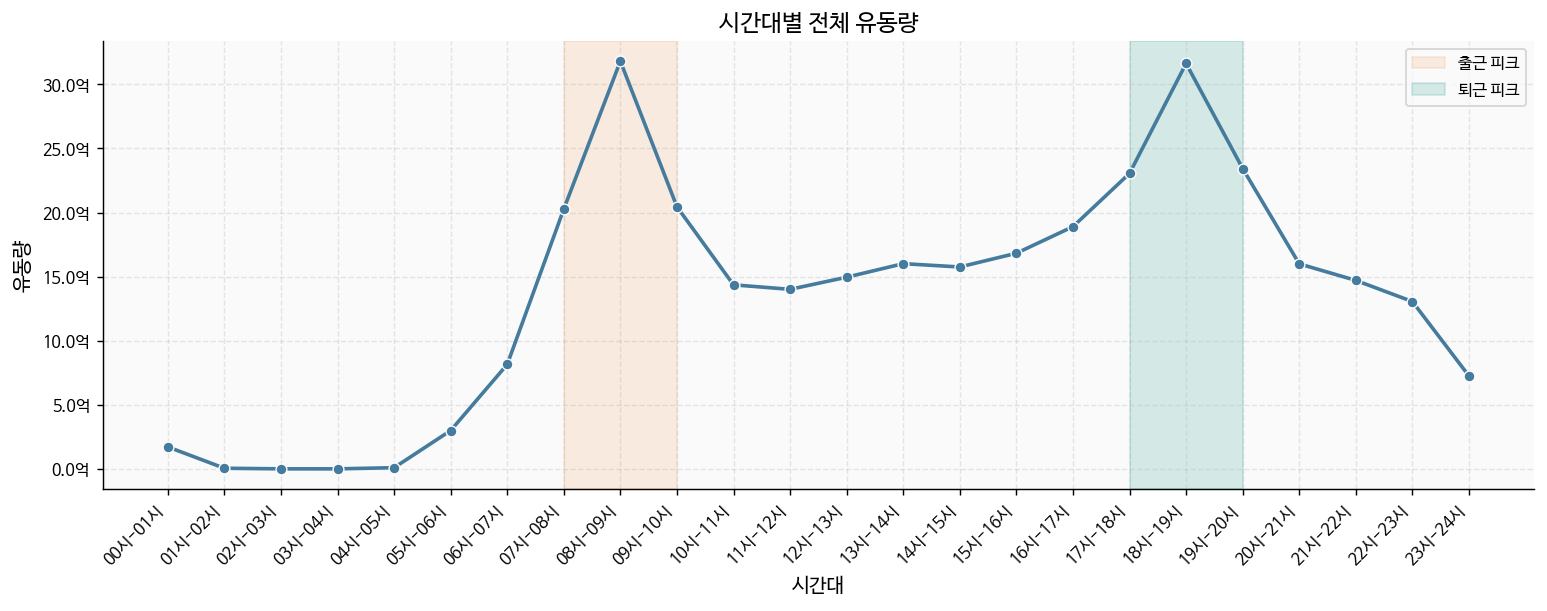

In [9]:
time_order = sorted(subway_long['시간대'].unique(), key=lambda x: int(x.split('시-')[0]))
time_plot = (
    subway_long
    .groupby('시간대', as_index=False)
    .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum'))
)
time_plot['시간대'] = pd.Categorical(time_plot['시간대'], categories=time_order, ordered=True)
time_plot = time_plot.sort_values('시간대')

top_time = time_plot.sort_values('유동량', ascending=False).head(5)

print('[상태] 시간대별 유동량 집계 완료')
display(top_time)

plt.figure(figsize=(12, 4.8))
sns.lineplot(data=time_plot, x='시간대', y='유동량', marker='o', color='#457B9D', linewidth=2)
plt.axvspan(time_order.index('07시-08시'), time_order.index('09시-10시'), color='#F4A261', alpha=0.18, label='출근 피크')
plt.axvspan(time_order.index('17시-18시'), time_order.index('19시-20시'), color='#2A9D8F', alpha=0.18, label='퇴근 피크')
plt.title('시간대별 전체 유동량')
plt.xlabel('시간대')
plt.ylabel('유동량')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e8:.1f}억'))
plt.legend()
plt.tight_layout()
plt.show()


### 4-2. 노선별 유동량 순위

노선별 유동량을 비교해 혼잡 관리 우선 노선을 확인한다.


[상태] 노선별 유동량 집계 완료


,호선명,승차인원,하차인원,유동량,유동량비중
1,2호선,3388603256,3431653117,6820256373,0.209576
6,7호선,1605058043,1576112651,3181170694,0.097753
4,5호선,1353695882,1340811951,2694507833,0.082798
3,4호선,1294643056,1306166302,2600809358,0.079919
2,3호선,1242376957,1246970635,2489347592,0.076494
12,경부선,1086198958,1083273677,2169472635,0.066665
19,분당선,813680986,842027612,1655708598,0.050877
5,6호선,784884369,772443274,1557327643,0.047854
15,경인선,737530067,724950185,1462480252,0.044940
0,1호선,611866031,599947184,1211813215,0.037237


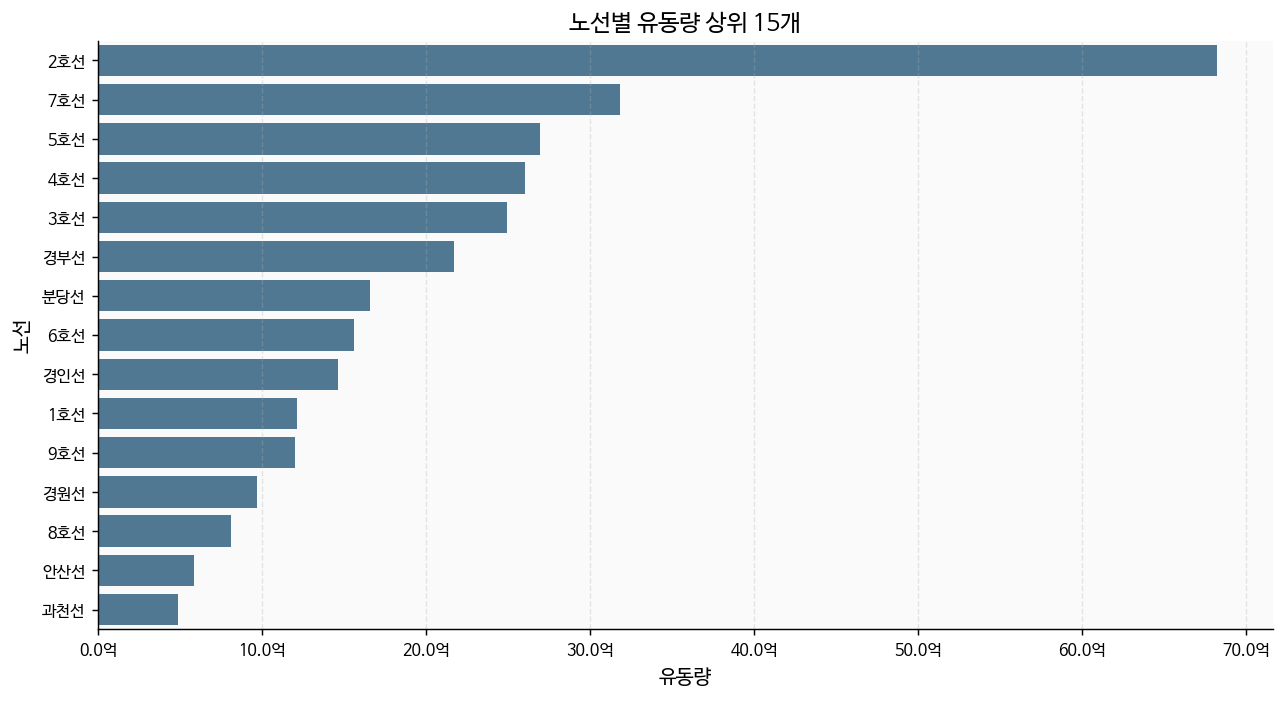

In [10]:
line_plot = line_summary.copy().sort_values('유동량', ascending=False)
line_plot['유동량비중'] = line_plot['유동량'] / line_plot['유동량'].sum()

print('[상태] 노선별 유동량 집계 완료')
display(line_plot.head(10))

plt.figure(figsize=(10, 5.5))
sns.barplot(data=line_plot.head(15), y='호선명', x='유동량', color='#457B9D')
plt.title('노선별 유동량 상위 15개')
plt.xlabel('유동량')
plt.ylabel('노선')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e8:.1f}억'))
plt.tight_layout()
plt.show()


### 4-3. 역별 유동량 순위

역별 유동량 상위 지점을 확인해 운영 자원 우선 투입 후보를 도출한다. 동일 역명이라도 노선이 다를 수 있으므로 `호선명+지하철역` 기준으로 비교한다.


[상태] 역별 유동량 상위 20개 산출 완료


,호선명,지하철역,승차인원,하차인원,유동량,상대혼잡도
11,2호선,강남,221578885,223946982,445525867,1.000000
72,2호선,홍대입구,167061781,178423216,345484997,0.775454
46,2호선,신림,159939203,155956392,315895595,0.709040
17,2호선,구로디지털단지,141533340,141637959,283171299,0.635589
45,2호선,신도림,134895914,134051594,268947508,0.603663
64,2호선,잠실(송파구청),135565212,129364026,264929238,0.594644
77,3호선,고속터미널,128974143,127197772,256171915,0.574988
2,1호선,서울역,125983971,116650582,242634553,0.544603
39,2호선,선릉,122263195,106687783,228950978,0.513889
426,경부선,영등포,110482542,116047383,226529925,0.508455


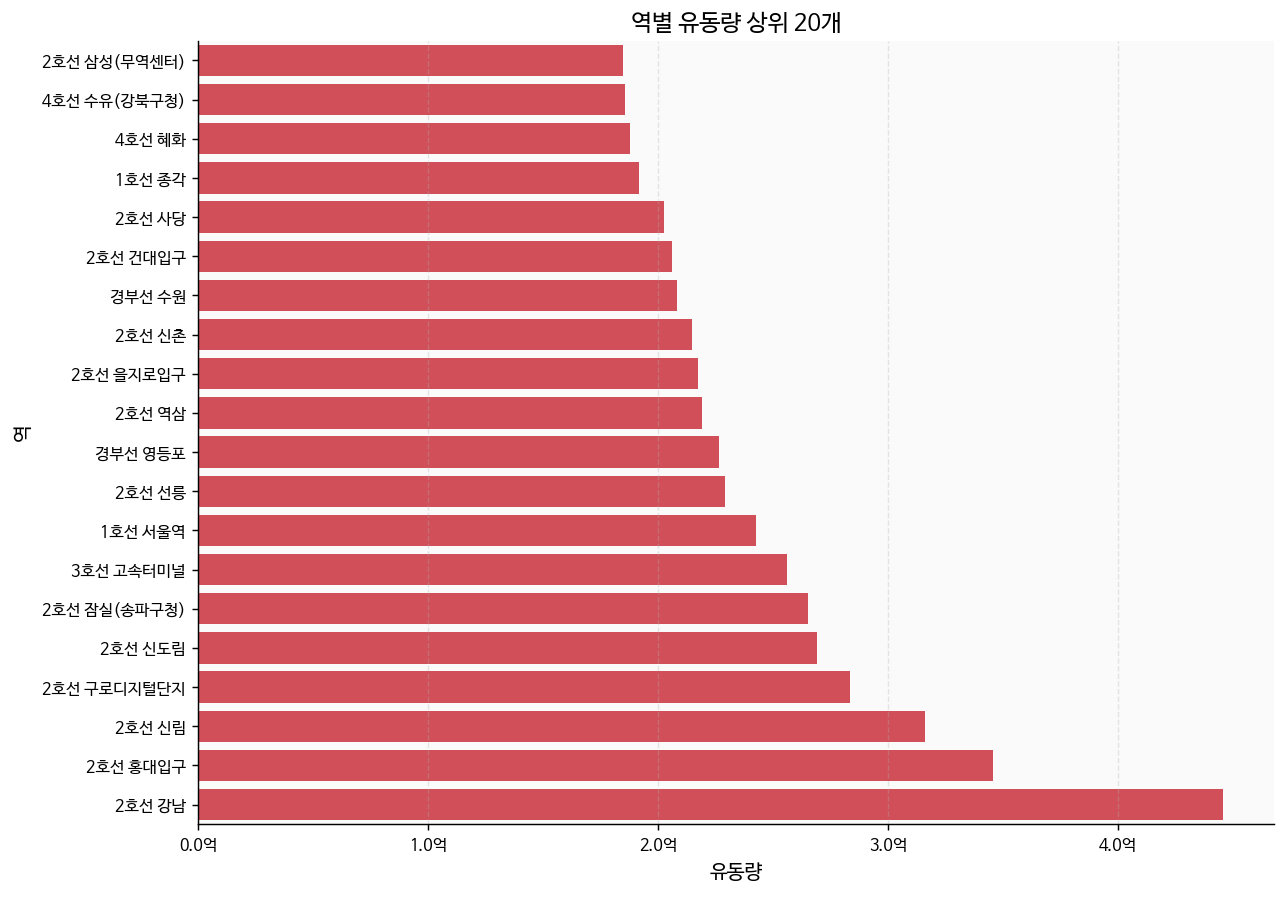

In [11]:
top_station = station_summary.head(20).copy()
top_station['역_노선'] = top_station['호선명'] + ' ' + top_station['지하철역']

print('[상태] 역별 유동량 상위 20개 산출 완료')
display(top_station[['호선명', '지하철역', '승차인원', '하차인원', '유동량', '상대혼잡도']])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_station.sort_values('유동량'), y='역_노선', x='유동량', color='#E63946')
plt.title('역별 유동량 상위 20개')
plt.xlabel('유동량')
plt.ylabel('역')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e8:.1f}억'))
plt.tight_layout()
plt.show()


### 4-4. 피크 시간대 혼잡 역 비교

출근 피크와 퇴근 피크의 상위 혼잡 역을 분리해 비교한다. 두 피크에서 반복 등장하는 역은 우선 관리 후보로 볼 수 있다.


[상태] 피크 시간대 상위 혼잡 역 비교 완료
  출근·퇴근 피크 공통 상위 역 수: 7
  공통 상위 역: ['1호선 서울역', '2호선 강남', '2호선 구로디지털단지', '2호선 선릉', '2호선 신도림', '2호선 신림', '2호선 잠실(송파구청)']


,피크구분,호선명,지하철역,승차인원,하차인원,유동량
11,출근 피크,2호선,강남,14443805,67386285,81830090
17,출근 피크,2호선,구로디지털단지,36578993,39140895,75719888
46,출근 피크,2호선,신림,59470572,12947879,72418451
53,출근 피크,2호선,역삼,5443141,56670009,62113150
262,출근 피크,7호선,가산디지털단지,4774143,55145827,59919970
39,출근 피크,2호선,선릉,7644268,48265936,55910204
45,출근 피크,2호선,신도림,31863586,20586576,52450162
61,출근 피크,2호선,을지로입구,3435523,46949813,50385336
2,출근 피크,1호선,서울역,13974889,35854560,49829449
64,출근 피크,2호선,잠실(송파구청),25116469,24377129,49493598


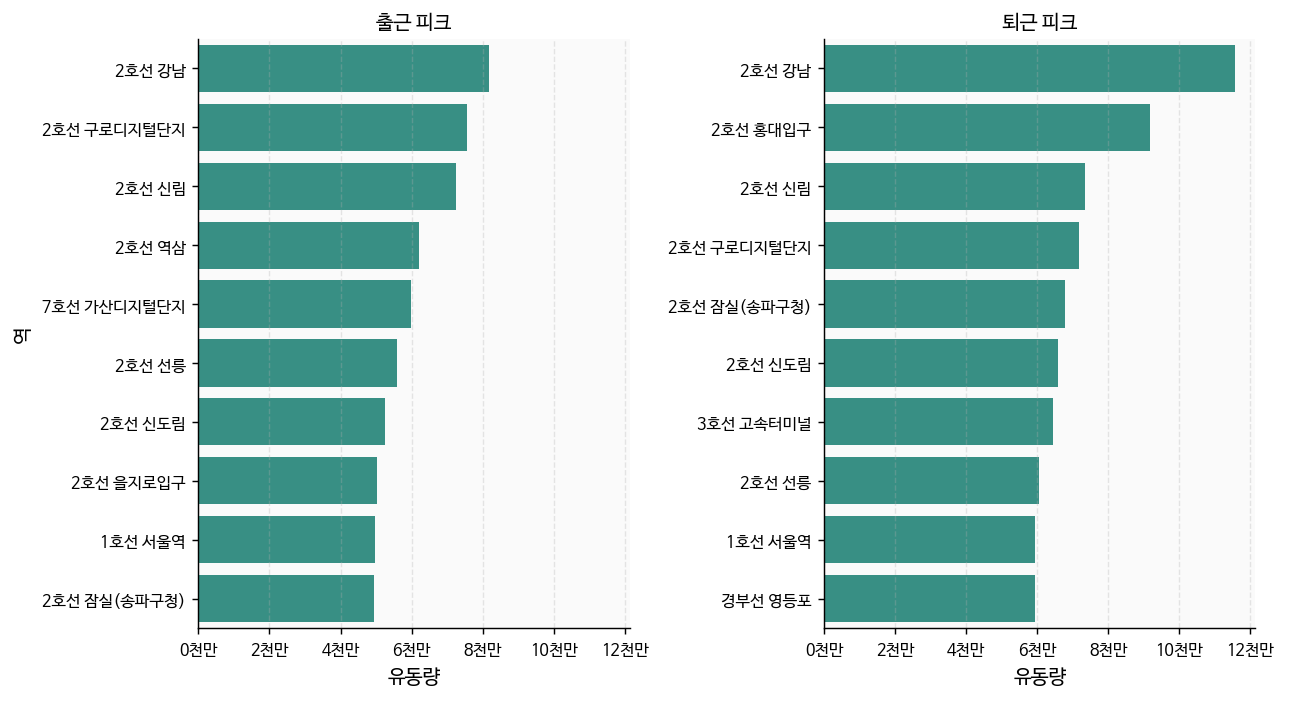

In [12]:
peak_top = (
    peak_summary
    .groupby('피크구분', group_keys=False)
    .apply(lambda x: x.nlargest(10, '유동량'))
    .copy()
)
peak_top['역_노선'] = peak_top['호선명'] + ' ' + peak_top['지하철역']

morning_top_set = set(peak_top.loc[peak_top['피크구분'] == '출근 피크', '역_노선'])
evening_top_set = set(peak_top.loc[peak_top['피크구분'] == '퇴근 피크', '역_노선'])
overlap_peak_stations = sorted(morning_top_set & evening_top_set)

print('[상태] 피크 시간대 상위 혼잡 역 비교 완료')
print(f'  출근·퇴근 피크 공통 상위 역 수: {len(overlap_peak_stations)}')
print(f'  공통 상위 역: {overlap_peak_stations}')
display(peak_top[['피크구분', '호선명', '지하철역', '승차인원', '하차인원', '유동량']])

g = sns.catplot(
    data=peak_top,
    kind='bar',
    y='역_노선',
    x='유동량',
    col='피크구분',
    sharey=False,
    color='#2A9D8F',
    height=5.5,
    aspect=0.9
)
g.set_titles('{col_name}')
g.set_axis_labels('유동량', '역')
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e7:.0f}천만'))
plt.tight_layout()
plt.show()


### 4-5. 승차형·하차형 흐름 유형 탐색

피크 시간대의 승차비중과 하차비중을 비교해 역의 흐름 유형을 탐색한다. 이 결과는 승차 대기열 관리, 하차 동선 관리, 혼합형 병목 관리 제안으로 연결된다.


[상태] 승차형·하차형 흐름 유형 분류 완료


,피크구분,흐름유형,역수,유동량
0,출근 피크,승차형,333,3276220529
1,출근 피크,하차형,185,2458960307
2,출근 피크,혼합형,167,1517380085
5,퇴근 피크,혼합형,292,3196656258
4,퇴근 피크,하차형,235,2565954898
3,퇴근 피크,승차형,158,2049008953


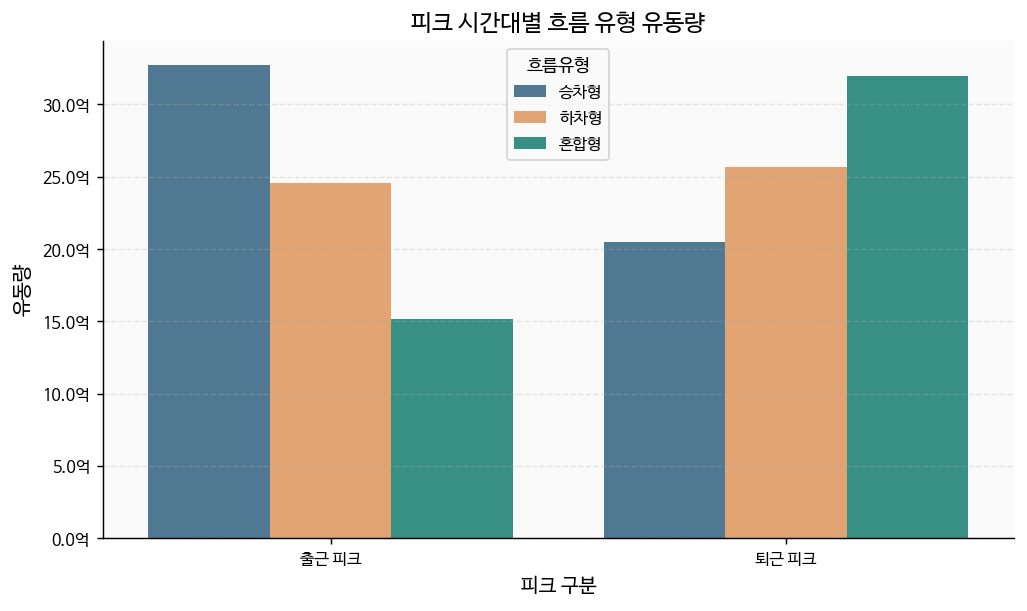

In [13]:
peak_flow_type = (
    subway_long[subway_long['피크구분'] != '비피크']
    .groupby(['피크구분', '호선명', '지하철역'], as_index=False)
    .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum'))
)
peak_flow_type['승차비중'] = peak_flow_type['승차인원'] / peak_flow_type['유동량']
peak_flow_type['하차비중'] = peak_flow_type['하차인원'] / peak_flow_type['유동량']

def classify_flow_type(row):
    if row['승차비중'] >= 0.6:
        return '승차형'
    if row['하차비중'] >= 0.6:
        return '하차형'
    return '혼합형'

peak_flow_type['흐름유형'] = peak_flow_type.apply(classify_flow_type, axis=1)
flow_type_summary = (
    peak_flow_type
    .groupby(['피크구분', '흐름유형'], as_index=False)
    .agg(역수=('지하철역', 'count'), 유동량=('유동량', 'sum'))
    .sort_values(['피크구분', '유동량'], ascending=[True, False])
)

print('[상태] 승차형·하차형 흐름 유형 분류 완료')
display(flow_type_summary)

plt.figure(figsize=(8, 4.8))
sns.barplot(data=flow_type_summary, x='피크구분', y='유동량', hue='흐름유형', palette=['#457B9D', '#F4A261', '#2A9D8F'])
plt.title('피크 시간대별 흐름 유형 유동량')
plt.xlabel('피크 구분')
plt.ylabel('유동량')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e8:.1f}억'))
plt.tight_layout()
plt.show()


### 4-6. Folium GeoJSON 기반 혼잡도 지도 시각화

역별 상대혼잡도와 우선순위 등급을 지도 위에 표시한다. 위치 데이터는 역명 표기 차이가 있을 수 있으므로, 지도 생성 전에 역명 정규화와 매칭률을 확인한다. 여기서는 역별 포인트 데이터를 GeoJSON FeatureCollection으로 변환한 뒤 `folium.GeoJson`으로 시각화한다.


In [14]:
try:
    import folium
except ImportError:
    !pip install -q folium
    import folium

import json

def normalize_station_name(name):
    name = str(name).strip().replace(' ', '')
    if name.endswith('역'):
        name = name[:-1]
    return name

location_map = location_raw.copy()
location_map['역명정규화'] = location_map['지하철역'].apply(normalize_station_name)
location_map = (
    location_map
    .sort_values(['역명정규화', '주소'])
    .drop_duplicates('역명정규화', keep='first')
)

station_map = station_summary.copy()
station_map['역명정규화'] = station_map['지하철역'].apply(normalize_station_name)
station_map = station_map.merge(
    location_map[['역명정규화', '주소', 'x좌표', 'y좌표']],
    on='역명정규화',
    how='left'
)

station_map['지도매칭여부'] = station_map[['x좌표', 'y좌표']].notna().all(axis=1)
matched_count = int(station_map['지도매칭여부'].sum())
total_count = len(station_map)
match_rate = matched_count / total_count
unmatched_station = station_map.loc[~station_map['지도매칭여부'], ['호선명', '지하철역']].head(20)

print('[상태] 지도 좌표 매칭 완료')
print(f'  매칭 성공: {matched_count:,} / {total_count:,} ({match_rate:.1%})')
if len(unmatched_station) > 0:
    print('[확인 필요] 좌표 미매칭 상위 20개')
    display(unmatched_station)

station_map_valid = station_map[station_map['지도매칭여부']].copy()
station_map_valid['지도반경'] = 4 + station_map_valid['상대혼잡도'] * 16

def congestion_color(value):
    if value >= 0.7:
        return '#E63946'
    if value >= 0.4:
        return '#F4A261'
    return '#457B9D'

station_map_valid['혼잡색상'] = station_map_valid['상대혼잡도'].apply(congestion_color)

features = []
for _, row in station_map_valid.iterrows():
    features.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [float(row['y좌표']), float(row['x좌표'])]
        },
        'properties': {
            '호선명': row['호선명'],
            '지하철역': row['지하철역'],
            '주소': row['주소'],
            '유동량': int(row['유동량']),
            '상대혼잡도': round(float(row['상대혼잡도']), 3),
            '반경': round(float(row['지도반경']), 2),
            '색상': row['혼잡색상']
        }
    })

station_geojson = {
    'type': 'FeatureCollection',
    'features': features
}

print('[상태] 역별 혼잡도 GeoJSON 생성 완료')
print(f'  GeoJSON feature 수: {len(features):,}')


[상태] 지도 좌표 매칭 완료
  매칭 성공: 601 / 685 (87.7%)
[확인 필요] 좌표 미매칭 상위 20개


,호선명,지하철역
5,2호선,잠실(송파구청)
7,1호선,서울역
18,4호선,수유(강북구청)
19,2호선,삼성(무역센터)
26,2호선,서울대입구(관악구청)
34,2호선,강변(동서울터미널)
40,3호선,양재(서초구청)
52,2호선,교대(법원.검찰청)
56,5호선,광화문(세종문화회관)
61,3호선,남부터미널(예술의전당)


[상태] 역별 혼잡도 GeoJSON 생성 완료
  GeoJSON feature 수: 601


In [15]:
center_lat = station_map_valid['x좌표'].mean()
center_lon = station_map_valid['y좌표'].mean()

subway_congestion_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

folium.GeoJson(
    station_geojson,
    name='역별 상대혼잡도',
    marker=folium.CircleMarker(radius=5, fill=True, fill_opacity=0.6, weight=1),
    tooltip=folium.GeoJsonTooltip(
        fields=['호선명', '지하철역', '유동량', '상대혼잡도'],
        aliases=['노선', '역', '유동량', '상대혼잡도'],
        localize=True,
        sticky=True
    ),
    popup=folium.GeoJsonPopup(
        fields=['호선명', '지하철역', '주소', '유동량', '상대혼잡도'],
        aliases=['노선', '역', '주소', '유동량', '상대혼잡도'],
        localize=True
    ),
    style_function=lambda feature: {
        'color': feature['properties']['색상'],
        'fillColor': feature['properties']['색상'],
        'fillOpacity': 0.58,
    },
).add_to(subway_congestion_map)

top_map_points = station_map_valid.sort_values('유동량', ascending=False).head(80)
for _, row in top_map_points.iterrows():
    folium.CircleMarker(
        location=[row['x좌표'], row['y좌표']],
        radius=row['지도반경'],
        color=row['혼잡색상'],
        fill=True,
        fill_color=row['혼잡색상'],
        fill_opacity=0.35,
        weight=1,
        tooltip=f"{row['호선명']} {row['지하철역']} | 유동량 {row['유동량']:,} | 상대혼잡도 {row['상대혼잡도']:.3f}",
    ).add_to(subway_congestion_map)

legend_html = '''
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 9999; background: white; padding: 10px 12px; border: 1px solid #BBBBBB; font-size: 13px;">
<b>상대혼잡도</b><br>
<span style="color:#E63946;">●</span> 0.70 이상<br>
<span style="color:#F4A261;">●</span> 0.40 이상<br>
<span style="color:#457B9D;">●</span> 0.40 미만<br>
</div>
'''
subway_congestion_map.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(subway_congestion_map)

map_output_path = 'subway_congestion_folium_map.html'
subway_congestion_map.save(map_output_path)
print('[상태] Folium 혼잡도 지도 생성 완료')
print(f'  저장 경로: {map_output_path}')

subway_congestion_map


[상태] Folium 혼잡도 지도 생성 완료
  저장 경로: subway_congestion_folium_map.html


## 5장. 핵심 인사이트 및 운영 우선순위 도출

5장은 EDA 결과를 의사결정에 사용할 수 있는 우선순위로 변환한다. 단순히 유동량이 많은 역을 나열하지 않고, 전체 유동량, 피크 유동량, 반복 혼잡 여부, 승하차 흐름 유형을 함께 고려한다.


### 5-1. 혼잡 관리 우선순위 점수 산출

역별 전체 유동량, 피크 유동량, 상대 혼잡도를 결합해 우선순위 점수를 산출한다. 이 점수는 실제 혼잡률이 아니라 운영 자원 배치 후보를 정하기 위한 상대 지표이다.


[상태] 혼잡 관리 우선순위 점수 산출 완료


,호선명,지하철역,유동량,피크유동량,전체유동량지수,피크유동량지수,우선순위점수,우선순위등급
0,2호선,강남,445525867,197518241,1.000000,1.000000,1.000000,A
2,2호선,신림,315895595,145811345,0.709040,0.738217,0.723628,A
1,2호선,홍대입구,345484997,131487959,0.775454,0.665700,0.720577,A
3,2호선,구로디지털단지,283171299,147480743,0.635589,0.746669,0.691129,A
4,2호선,신도림,268947508,118323538,0.603663,0.599051,0.601357,A
5,2호선,잠실(송파구청),264929238,117432265,0.594644,0.594539,0.594591,A
8,2호선,선릉,228950978,116402174,0.513889,0.589324,0.551606,A
10,2호선,역삼,218795215,120028823,0.491094,0.607685,0.549390,A
7,1호선,서울역,242634553,109188403,0.544603,0.552802,0.548702,A
6,3호선,고속터미널,256171915,94522526,0.574988,0.478551,0.526769,A


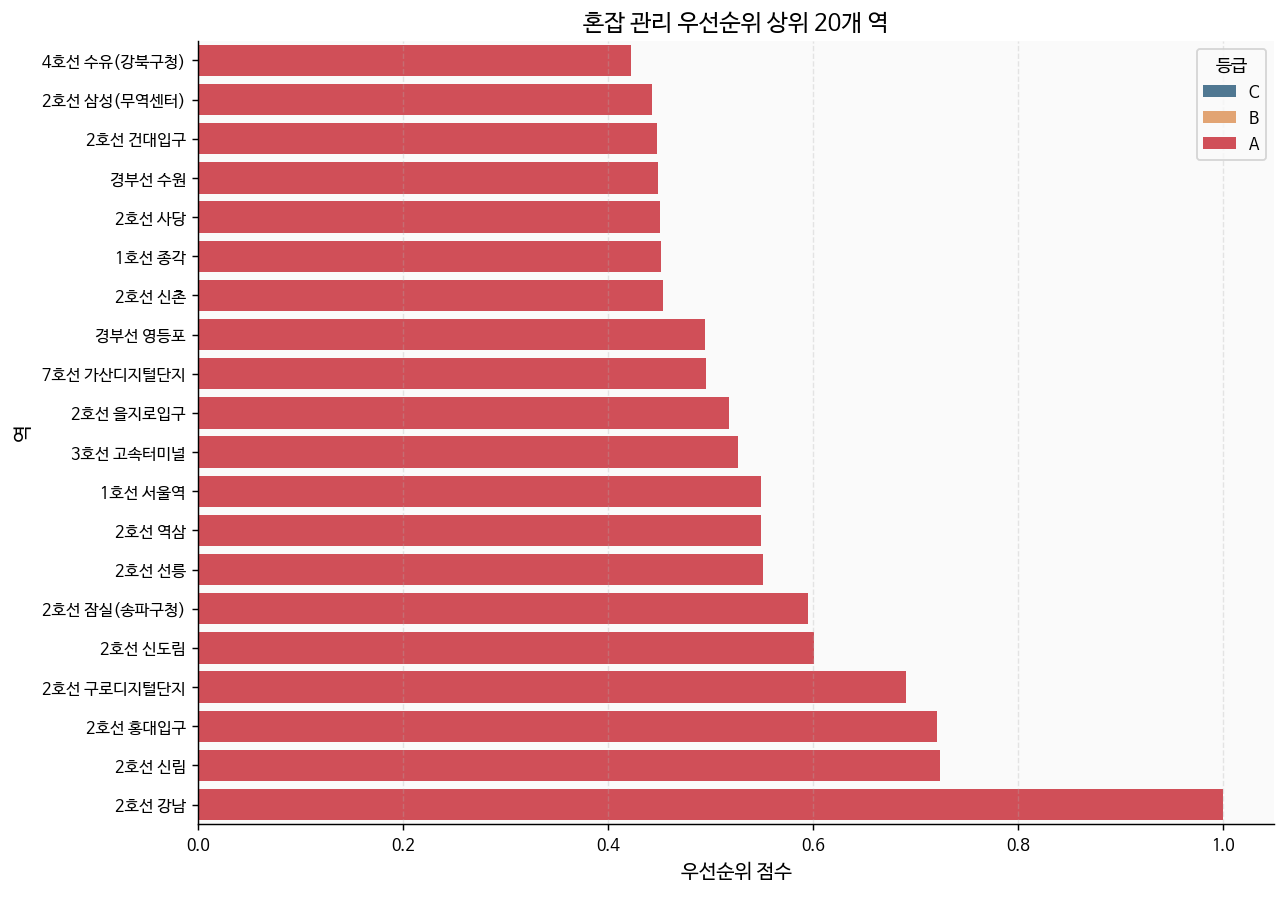

In [16]:
station_peak_total = (
    subway_long[subway_long['피크구분'] != '비피크']
    .groupby(['호선명', '지하철역'], as_index=False)
    .agg(피크유동량=('유동량', 'sum'))
)

priority_df = station_summary.merge(
    station_peak_total,
    on=['호선명', '지하철역'],
    how='left'
)
priority_df['피크유동량'] = priority_df['피크유동량'].fillna(0)
priority_df['전체유동량지수'] = priority_df['유동량'] / priority_df['유동량'].max()
priority_df['피크유동량지수'] = priority_df['피크유동량'] / priority_df['피크유동량'].max()
priority_df['우선순위점수'] = (
    priority_df['전체유동량지수'] * 0.5
    + priority_df['피크유동량지수'] * 0.5
)

priority_df['우선순위등급'] = pd.qcut(
    priority_df['우선순위점수'].rank(method='first'),
    q=[0, 0.7, 0.9, 1.0],
    labels=['C', 'B', 'A']
)

priority_df = priority_df.sort_values('우선순위점수', ascending=False)
top_priority = priority_df.head(20).copy()
top_priority['역_노선'] = top_priority['호선명'] + ' ' + top_priority['지하철역']

print('[상태] 혼잡 관리 우선순위 점수 산출 완료')
display(top_priority[['호선명', '지하철역', '유동량', '피크유동량', '전체유동량지수', '피크유동량지수', '우선순위점수', '우선순위등급']])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_priority.sort_values('우선순위점수'), y='역_노선', x='우선순위점수', hue='우선순위등급', dodge=False, palette={'A': '#E63946', 'B': '#F4A261', 'C': '#457B9D'})
plt.title('혼잡 관리 우선순위 상위 20개 역')
plt.xlabel('우선순위 점수')
plt.ylabel('역')
plt.legend(title='등급')
plt.tight_layout()
plt.show()


### 5-2. 피크 반복 혼잡 역 식별

출근 피크와 퇴근 피크 모두에서 상위권에 포함되는 역은 하루 중 여러 시간대에 반복적으로 혼잡한 지점일 가능성이 높다.


In [17]:
morning_rank = (
    peak_summary[peak_summary['피크구분'] == '출근 피크']
    .sort_values('유동량', ascending=False)
    .assign(출근피크순위=lambda df: range(1, len(df) + 1))
    [['호선명', '지하철역', '출근피크순위', '유동량']]
    .rename(columns={'유동량': '출근피크유동량'})
)
evening_rank = (
    peak_summary[peak_summary['피크구분'] == '퇴근 피크']
    .sort_values('유동량', ascending=False)
    .assign(퇴근피크순위=lambda df: range(1, len(df) + 1))
    [['호선명', '지하철역', '퇴근피크순위', '유동량']]
    .rename(columns={'유동량': '퇴근피크유동량'})
)

repeat_peak = morning_rank.merge(evening_rank, on=['호선명', '지하철역'], how='inner')
repeat_peak['피크반복점수'] = (1 / repeat_peak['출근피크순위']) + (1 / repeat_peak['퇴근피크순위'])
repeat_peak = repeat_peak.sort_values('피크반복점수', ascending=False).head(20)

print('[상태] 피크 반복 혼잡 역 식별 완료')
display(repeat_peak)


[상태] 피크 반복 혼잡 역 식별 완료


,호선명,지하철역,출근피크순위,출근피크유동량,퇴근피크순위,퇴근피크유동량,피크반복점수
0,2호선,강남,1,81830090,1,115688151,2.000000
1,2호선,구로디지털단지,2,75719888,4,71760855,0.750000
2,2호선,신림,3,72418451,3,73392894,0.666667
14,2호선,홍대입구,15,39847825,2,91640134,0.566667
3,2호선,역삼,4,62113150,11,57915673,0.340909
6,2호선,신도림,7,52450162,6,65873376,0.309524
9,2호선,잠실(송파구청),10,49493598,5,67938667,0.300000
5,2호선,선릉,6,55910204,8,60491970,0.291667
4,7호선,가산디지털단지,5,59919970,13,54901634,0.276923
8,1호선,서울역,9,49829449,9,59358954,0.222222


### 5-3. 역 유형별 운영 제안 테이블

우선순위 상위 역에 피크 흐름 유형을 결합해 역별 운영 제안 방향을 만든다. 이 표는 최종 결론 장에서 실행 제안의 근거로 사용한다.


In [18]:
station_flow_main = (
    peak_flow_type
    .sort_values('유동량', ascending=False)
    .groupby(['호선명', '지하철역'], as_index=False)
    .first()[['호선명', '지하철역', '피크구분', '흐름유형', '승차비중', '하차비중']]
)

recommendation_df = top_priority[['호선명', '지하철역', '유동량', '피크유동량', '우선순위점수', '우선순위등급']].merge(
    station_flow_main,
    on=['호선명', '지하철역'],
    how='left'
)

def make_action(flow_type):
    if flow_type == '승차형':
        return '승차 대기열 관리, 개찰구·승강장 진입 안내 강화'
    if flow_type == '하차형':
        return '하차 동선 분산, 출구·환승 안내 강화'
    if flow_type == '혼합형':
        return '승하차 동선 분리, 환승 병목 구간 집중 관리'
    return '확인 필요'

recommendation_df['운영제안'] = recommendation_df['흐름유형'].apply(make_action)

print('[상태] 역 유형별 운영 제안 테이블 생성 완료')
display(recommendation_df)


[상태] 역 유형별 운영 제안 테이블 생성 완료


,호선명,지하철역,유동량,피크유동량,우선순위점수,우선순위등급,피크구분,흐름유형,승차비중,하차비중,운영제안
0,2호선,강남,445525867,197518241,1.000000,A,퇴근 피크,혼합형,0.587573,0.412427,"승하차 동선 분리, 환승 병목 구간 집중 관리"
1,2호선,신림,315895595,145811345,0.723628,A,퇴근 피크,하차형,0.305091,0.694909,"하차 동선 분산, 출구·환승 안내 강화"
2,2호선,홍대입구,345484997,131487959,0.720577,A,퇴근 피크,혼합형,0.446858,0.553142,"승하차 동선 분리, 환승 병목 구간 집중 관리"
3,2호선,구로디지털단지,283171299,147480743,0.691129,A,출근 피크,혼합형,0.483083,0.516917,"승하차 동선 분리, 환승 병목 구간 집중 관리"
4,2호선,신도림,268947508,118323538,0.601357,A,퇴근 피크,혼합형,0.439259,0.560741,"승하차 동선 분리, 환승 병목 구간 집중 관리"
5,2호선,잠실(송파구청),264929238,117432265,0.594591,A,퇴근 피크,혼합형,0.521142,0.478858,"승하차 동선 분리, 환승 병목 구간 집중 관리"
6,2호선,선릉,228950978,116402174,0.551606,A,퇴근 피크,승차형,0.784794,0.215206,"승차 대기열 관리, 개찰구·승강장 진입 안내 강화"
7,2호선,역삼,218795215,120028823,0.549390,A,출근 피크,하차형,0.087633,0.912367,"하차 동선 분산, 출구·환승 안내 강화"
8,1호선,서울역,242634553,109188403,0.548702,A,퇴근 피크,승차형,0.651239,0.348761,"승차 대기열 관리, 개찰구·승강장 진입 안내 강화"
9,3호선,고속터미널,256171915,94522526,0.526769,A,퇴근 피크,혼합형,0.535050,0.464950,"승하차 동선 분리, 환승 병목 구간 집중 관리"


### 5-4. 핵심 인사이트 요약

아래 셀은 분석 결과를 보고서 문장으로 옮기기 위한 핵심 수치를 자동으로 정리한다. 수치는 코드 실행 결과에 따라 확정한다.


In [19]:
top_time_name = top_time.iloc[0]['시간대']
top_line_name = line_plot.iloc[0]['호선명']
top_station_line = priority_df.iloc[0]['호선명']
top_station_name = priority_df.iloc[0]['지하철역']
a_grade_count = int((priority_df['우선순위등급'] == 'A').sum())

insight_summary = pd.DataFrame({
    '구분': ['시간', '노선', '역', '우선순위'],
    '핵심 결과': [
        f'전체 유동량이 가장 큰 시간대는 {top_time_name}이다.',
        f'전체 유동량이 가장 큰 노선은 {top_line_name}이다.',
        f'혼잡 관리 우선순위가 가장 높은 역은 {top_station_line} {top_station_name}이다.',
        f'A등급 우선 관리 대상은 {a_grade_count}개 역이다.'
    ],
    '제안 연결': [
        '피크 시간대 집중 관리',
        '노선 단위 관리 우선순위',
        '고혼잡 역 우선순위 지정',
        '운영 자원 단계별 배치'
    ]
})

print('[상태] 핵심 인사이트 요약 생성 완료')
display(insight_summary)


[상태] 핵심 인사이트 요약 생성 완료


,구분,핵심 결과,제안 연결
0,시간,전체 유동량이 가장 큰 시간대는 08시-09시이다.,피크 시간대 집중 관리
1,노선,전체 유동량이 가장 큰 노선은 2호선이다.,노선 단위 관리 우선순위
2,역,혼잡 관리 우선순위가 가장 높은 역은 2호선 강남이다.,고혼잡 역 우선순위 지정
3,우선순위,A등급 우선 관리 대상은 69개 역이다.,운영 자원 단계별 배치


### 5-5. 피라미드 근거별 통계분석 정리

1장의 피라미드 근거를 통계분석 결과로 정리한다. 유동량 분포는 정규성을 가정하기 어렵고 역·시간대별 편차가 크므로, 평균 차이 검정은 비모수 검정인 Kruskal-Wallis 검정을 사용한다. 범주형 흐름 유형은 카이제곱 검정으로 확인한다.


In [20]:
def epsilon_squared_kruskal(h_stat, n, k):
    if n <= k:
        return np.nan
    return max(0, (h_stat - k + 1) / (n - k))

def cramers_v(chi2, contingency_table):
    n = contingency_table.to_numpy().sum()
    r, c = contingency_table.shape
    denom = n * (min(r - 1, c - 1))
    if denom == 0:
        return np.nan
    return np.sqrt(chi2 / denom)

def format_p_value(p_value):
    if p_value < 0.001:
        return 'p<0.001'
    return f'p={p_value:.3f}'

# 근거 1: 시간대별 유동량 차이
time_monthly = (
    subway_long
    .groupby(['사용월', '시간대'], as_index=False)
    .agg(유동량=('유동량', 'sum'))
)
time_groups = [group['유동량'].values for _, group in time_monthly.groupby('시간대')]
time_h, time_p = stats.kruskal(*time_groups)
time_effect = epsilon_squared_kruskal(time_h, len(time_monthly), time_monthly['시간대'].nunique())

# 근거 2: 노선별 유동량 차이 및 역별 집중도
line_monthly = (
    subway_long
    .groupby(['사용월', '호선명'], as_index=False)
    .agg(유동량=('유동량', 'sum'))
)
line_groups = [group['유동량'].values for _, group in line_monthly.groupby('호선명')]
line_h, line_p = stats.kruskal(*line_groups)
line_effect = epsilon_squared_kruskal(line_h, len(line_monthly), line_monthly['호선명'].nunique())
top5_station_share = station_summary.head(5)['유동량'].sum() / station_summary['유동량'].sum()
top20_station_share = station_summary.head(20)['유동량'].sum() / station_summary['유동량'].sum()

# 근거 3: 피크 구분과 흐름 유형의 연관성
flow_contingency = pd.crosstab(peak_flow_type['피크구분'], peak_flow_type['흐름유형'])
flow_chi2, flow_p, flow_dof, flow_expected = stats.chi2_contingency(flow_contingency)
flow_effect = cramers_v(flow_chi2, flow_contingency)

stat_pyramid_summary = pd.DataFrame({
    '피라미드 근거': ['시간대별 집중', '공간별 집중', '흐름별 유형'],
    '통계분석': ['Kruskal-Wallis 검정', 'Kruskal-Wallis 검정 + 집중도', '카이제곱 독립성 검정'],
    '핵심 통계량': [
        f'H={time_h:.2f}, {format_p_value(time_p)}, epsilon²={time_effect:.3f}',
        f'H={line_h:.2f}, {format_p_value(line_p)}, epsilon²={line_effect:.3f}',
        f'χ²={flow_chi2:.2f}, {format_p_value(flow_p)}, Cramer\'s V={flow_effect:.3f}'
    ],
    '보조 지표': [
        f'최혼잡 시간대: {top_time_name}',
        f'상위 5개 역 비중: {top5_station_share:.1%}, 상위 20개 역 비중: {top20_station_share:.1%}',
        '피크 구분별 승차형·하차형·혼합형 분포 비교'
    ],
    '해석': [
        '시간대별 유동량 차이가 통계적으로 확인되면 피크 시간대 집중 관리의 근거가 된다.',
        '노선별 차이와 상위 역 집중도가 확인되면 고혼잡 역 우선순위 지정의 근거가 된다.',
        '피크 시간대와 흐름 유형의 연관성이 확인되면 역 유형별 맞춤 대응의 근거가 된다.'
    ]
})

print('[상태] 피라미드 근거별 통계분석 정리 완료')
display(stat_pyramid_summary)
display(flow_contingency)


[상태] 피라미드 근거별 통계분석 정리 완료


,피라미드 근거,통계분석,핵심 통계량,보조 지표,해석
0,시간대별 집중,Kruskal-Wallis 검정,"H=1720.89, p<0.001, epsilon²=0.919",최혼잡 시간대: 08시-09시,시간대별 유동량 차이가 통계적으로 확인되면 피크 시간대 집중 관리의 근거가 된다.
1,공간별 집중,Kruskal-Wallis 검정 + 집중도,"H=1840.58, p<0.001, epsilon²=0.971","상위 5개 역 비중: 5.1%, 상위 20개 역 비중: 15.0%",노선별 차이와 상위 역 집중도가 확인되면 고혼잡 역 우선순위 지정의 근거가 된다.
2,흐름별 유형,카이제곱 독립성 검정,"χ²=102.37, p<0.001, Cramer's V=0.273",피크 구분별 승차형·하차형·혼합형 분포 비교,피크 시간대와 흐름 유형의 연관성이 확인되면 역 유형별 맞춤 대응의 근거가 된다.


흐름유형,승차형,하차형,혼합형
피크구분,,,
출근 피크,333,185,167
퇴근 피크,158,235,292


## 6장. 최종 결론 및 제안

본 분석의 결론은 서울 지하철 혼잡 관리를 전체 평균 기준이 아니라 `피크 시간대`, `고혼잡 역`, `승하차 흐름 유형` 기준으로 선별 설계해야 한다는 것이다. 분석 결과 기준으로 최혼잡 시간대는 `08시-09시`, 최혼잡 노선은 `2호선`, 최우선 관리 역은 `2호선 강남`으로 확인된다.


### 6-1. 핵심 결론

| 결론 | 근거 | 의미 |
|---|---|---|
| 혼잡은 특정 시간대에 집중된다 | 시간대별 유동량 차이 검정 및 상위 시간대 확인 | 상시 대응보다 피크 시간대 집중 대응이 필요하다. |
| 혼잡은 특정 노선·역에 집중된다 | 노선별 유동량 차이 검정 및 상위 역 집중도 확인 | 운영 자원은 모든 역에 균등 배치하기보다 고혼잡 역부터 배치해야 한다. |
| 승하차 흐름에 따라 대응 방식이 달라져야 한다 | 피크 구분과 흐름 유형의 연관성 검정 | 대기열 관리, 하차 동선 관리, 환승 병목 관리를 구분해야 한다. |
| 정기 모니터링 체계가 필요하다 | 월 단위 데이터로 반복 추적 가능 | 일회성 분석보다 월별 혼잡 지표 관리가 적합하다. |


### 6-2. 실행 제안

| 제안 | 실행 방향 | 우선 적용 대상 |
|---|---|---|
| 피크 시간대 집중 관리 | 출근·퇴근 피크에 안전요원, 안내 방송, 혼잡 안내를 집중한다. | `08시-09시`, 퇴근 피크 상위 시간대 |
| 고혼잡 역 우선순위 지정 | 우선순위점수 기준 `A/B/C` 등급으로 관리 대상을 나눈다. | A등급 `69개` 역, 특히 `2호선 강남` 등 상위 역 |
| 역 유형별 맞춤 대응 | 승차형은 대기열, 하차형은 출구 동선, 혼합형은 환승 병목을 관리한다. | 5-3 운영 제안 테이블의 상위 혼잡 역 |
| 월별 모니터링 체계 구축 | 동일 지표로 매월 시간대·노선·역별 변화를 추적한다. | 전체 노선 및 A등급 역 |


### 6-3. 한계 및 추가 확인 필요 사항

| 항목 | 판단 |
|---|---|
| 실제 열차 혼잡률 | 현재 데이터에는 차량 정원, 운행 횟수, 열차별 탑승 인원이 없어 `확인 필요` |
| 승강장 혼잡도 | 승강장 면적, 체류 인원, 동선 데이터가 없어 `확인 필요` |
| 정책 효과 검증 | 정책 시행일, 대상역, 비교역 정보가 없어 본 보고서 범위 밖 |
| 위치 기반 분석 | 역명 중복과 표기 차이로 좌표 매칭률 확인 후 해석 필요 |

따라서 본 보고서는 실제 혼잡률 확정 보고서가 아니라, 승하차 유동량 기반의 운영 우선순위 제안 보고서로 해석한다.
